# SINGLE-RULE BACK-TESTING VERSUS DATA MINING

## Objectif pédagogique

Ce notebook explique la différence fondamentale entre un **back-test d’une règle unique** et le **minage de données** appliqué au trading.

L’idée centrale est simple :

> Un back-test unique mesure une hypothèse.  
> Le minage de données sélectionne le meilleur résultat parmi plusieurs essais.

Cette différence change complètement la signification statistique du profit observé.

## 1. Idée centrale

David Aronson distingue deux situations :

| Situation | Processus | Interprétation du résultat |
|---|---:|---|
| **Règle unique** | Une idée est testée une seule fois | Le profit observé est un **estimateur** |
| **Minage de données** | Plusieurs règles sont testées et comparées | Le profit observé est un **critère de sélection** |

> Le danger ne vient pas du back-test lui-même.  
> Le danger vient du fait de chercher jusqu’à trouver quelque chose qui marche sur le passé.

## 2. Back-test unique : processus linéaire

Dans un **back-test d’une règle unique**, le chercheur fait ceci :

1. Il formule une hypothèse avant de regarder les résultats.
2. Il code la règle.
3. Il teste la règle une seule fois.
4. Il accepte ou rejette l’idée.

La logique est **linéaire**.

$$
\text{Idée} \rightarrow \text{Règle} \rightarrow \text{Back-test} \rightarrow \text{Décision}
$$

La performance observée peut être vue comme une estimation de la performance future :

$$
\hat{\mu}_{\text{single}} = \frac{1}{n}\sum_{t=1}^{n} r_t
$$

où $\hat{\mu}_{\text{single}}$ représente la moyenne observée des rendements de la règle testée.

## 3. Minage de données : processus cyclique

Dans le **minage de données**, le chercheur ne teste pas une seule règle.

Il teste une règle, observe le résultat, modifie la règle, re-teste, puis recommence.

La logique devient **cyclique** :

$$
\text{Tester} \rightarrow \text{Observer} \rightarrow \text{Modifier} \rightarrow \text{Re-tester}
$$

Le résultat final n’est plus une simple estimation.

C’est le maximum observé parmi plusieurs essais :

$$
\hat{\mu}_{\text{minée}} = \max(\hat{\mu}_1, \hat{\mu}_2, \ldots, \hat{\mu}_k)
$$

où $k$ représente le nombre de règles ou variantes testées.

> Plus $k$ augmente, plus la probabilité de trouver une règle apparemment excellente par hasard augmente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def simulate_strategy_returns(n_days=252, true_edge=0.0, volatility=0.01, rng=None):
    """Simule les rendements journaliers d'une stratégie."""
    if rng is None:
        rng = np.random.default_rng()
    return rng.normal(loc=true_edge, scale=volatility, size=n_days)

def annualized_return(daily_returns):
    """Approximation simple du rendement annualisé moyen."""
    return np.mean(daily_returns) * 252

def sharpe_like(daily_returns):
    """Ratio de Sharpe simplifié sans taux sans risque."""
    std = np.std(daily_returns, ddof=1)
    if std == 0:
        return np.nan
    return np.mean(daily_returns) / std * np.sqrt(252)

## 4. Exemple 1 — Une règle unique sans edge réel

On simule une stratégie qui n’a **aucun edge réel**.

Son espérance vraie est :

$$
\mu = 0
$$

Cela signifie que la règle ne prédit rien.

Mais sur un seul échantillon historique, elle peut quand même afficher un profit positif ou négatif par hasard.

In [2]:
single_rule_returns = simulate_strategy_returns(
    n_days=252,
    true_edge=0.0,
    volatility=0.01,
    rng=rng
)

single_equity = 100_000 * np.cumprod(1 + single_rule_returns)

single_stats = pd.DataFrame({
    "Mesure": ["Rendement annualisé observé", "Sharpe simplifié observé"],
    "Valeur": [annualized_return(single_rule_returns), sharpe_like(single_rule_returns)]
})

single_stats

,Mesure,Valeur
0,Rendement annualisé observé,-0.121893
1,Sharpe simplifié observé,-0.818934


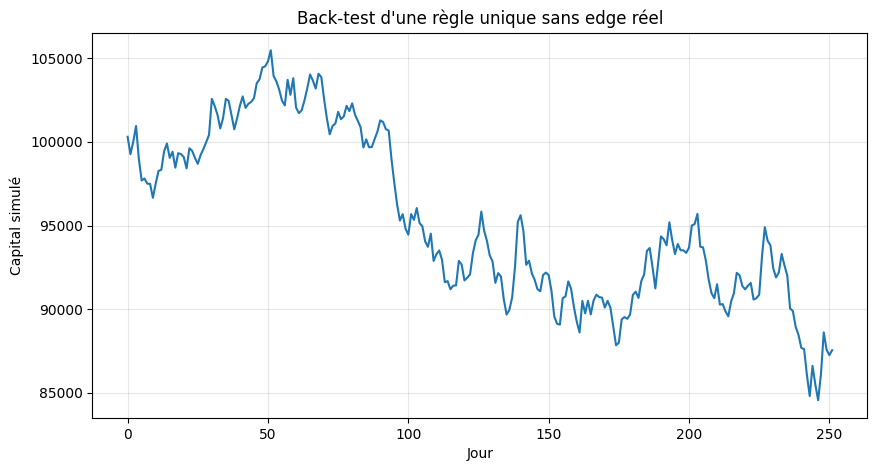

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(single_equity)
plt.title("Back-test d'une règle unique sans edge réel")
plt.xlabel("Jour")
plt.ylabel("Capital simulé")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Lecture statistique du back-test unique

Le résultat observé peut être bon ou mauvais.

Mais si la règle a été choisie **avant** le test, alors le résultat est une mesure directe de cette règle.

En moyenne, si on répétait l’expérience sur beaucoup d’échantillons indépendants, l’estimation tournerait autour de la vraie valeur :

$$
\mathbb{E}[\hat{\mu}_{\text{single}}] = \mu
$$

Si $\mu = 0$, alors l’estimateur n’est pas structurellement gonflé.

> Le back-test unique peut être chanceux, mais il n’est pas automatiquement biaisé par le processus de sélection.

## 6. Exemple 2 — Minage de données sur 500 règles sans edge

Maintenant, on simule 500 règles.

Aucune n’a de vrai edge.

Toutes ont :

$$
\mu_1 = \mu_2 = \cdots = \mu_{500} = 0
$$

Mais on sélectionne ensuite celle qui a eu le meilleur résultat sur le passé.

C’est exactement le piège du **selection criterion**.

In [4]:
n_rules = 500
n_days = 252

all_rules = np.array([
    simulate_strategy_returns(
        n_days=n_days,
        true_edge=0.0,
        volatility=0.01,
        rng=rng
    )
    for _ in range(n_rules)
])

in_sample_scores = np.array([annualized_return(rule) for rule in all_rules])
best_index = np.argmax(in_sample_scores)
best_in_sample_returns = all_rules[best_index]

summary = pd.DataFrame({
    "Mesure": [
        "Nombre de règles testées",
        "Meilleur rendement annualisé in-sample",
        "Rendement annualisé médian des règles",
        "Index de la règle sélectionnée"
    ],
    "Valeur": [
        n_rules,
        in_sample_scores[best_index],
        np.median(in_sample_scores),
        best_index
    ]
})

summary

,Mesure,Valeur
0,Nombre de règles testées,500.000000
1,Meilleur rendement annualisé in-sample,0.481437
2,Rendement annualisé médian des règles,-0.012420
3,Index de la règle sélectionnée,248.000000


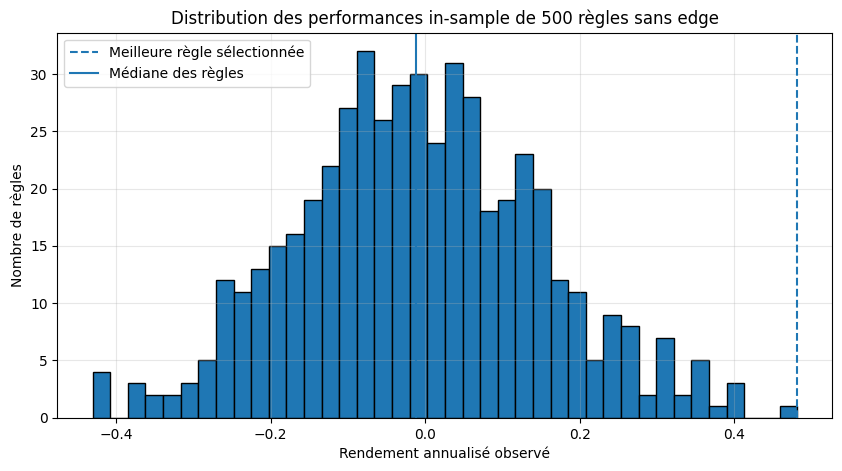

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(in_sample_scores, bins=40, edgecolor="black")
plt.axvline(in_sample_scores[best_index], linestyle="--", label="Meilleure règle sélectionnée")
plt.axvline(np.median(in_sample_scores), linestyle="-", label="Médiane des règles")
plt.title("Distribution des performances in-sample de 500 règles sans edge")
plt.xlabel("Rendement annualisé observé")
plt.ylabel("Nombre de règles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Pourquoi le meilleur résultat est trompeur

Même si toutes les règles sont nulles en réalité, certaines auront de bons résultats par hasard.

Le minage de données sélectionne précisément ces résultats extrêmes.

Mathématiquement, le score retenu est :

$$
\max(\hat{\mu}_1, \hat{\mu}_2, \ldots, \hat{\mu}_{500})
$$

Ce maximum n’est pas représentatif de la performance moyenne future.

Il représente surtout la meilleure coïncidence statistique trouvée dans le passé.

> La règle sélectionnée n’est pas forcément la plus intelligente.  
> C’est souvent celle qui a eu le plus de chance dans l’échantillon testé.

## 8. Exemple 3 — Détérioration out-of-sample

Pour vérifier si la règle sélectionnée avait un vrai edge, on la teste sur une nouvelle période indépendante.

Comme elle n’a aucun vrai edge dans notre simulation, son résultat futur devrait revenir vers :

$$
\mu = 0
$$

C’est le phénomène de **détérioration out-of-sample**.

In [6]:
out_of_sample_returns = simulate_strategy_returns(
    n_days=252,
    true_edge=0.0,
    volatility=0.01,
    rng=rng
)

comparison = pd.DataFrame({
    "Période": ["In-sample sélectionné", "Out-of-sample indépendant"],
    "Rendement annualisé": [
        annualized_return(best_in_sample_returns),
        annualized_return(out_of_sample_returns)
    ],
    "Sharpe simplifié": [
        sharpe_like(best_in_sample_returns),
        sharpe_like(out_of_sample_returns)
    ]
})

comparison

,Période,Rendement annualisé,Sharpe simplifié
0,In-sample sélectionné,0.481437,2.972176
1,Out-of-sample indépendant,0.191267,1.179953


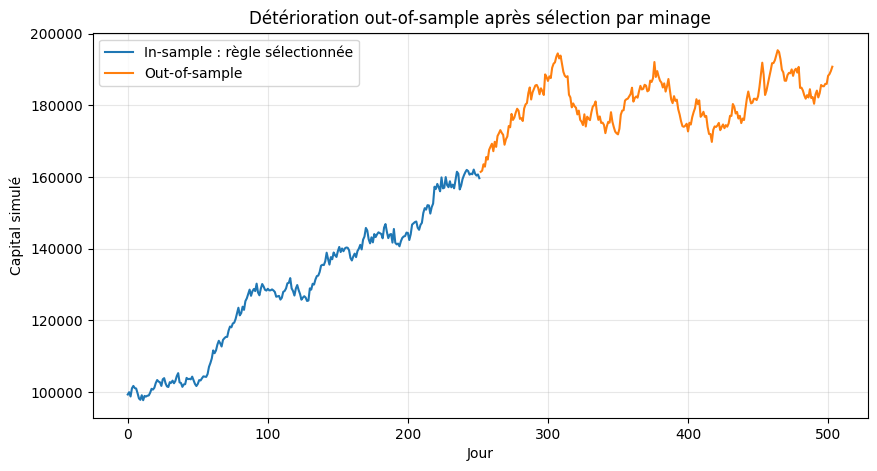

In [7]:
best_equity_is = 100_000 * np.cumprod(1 + best_in_sample_returns)
best_equity_oos = best_equity_is[-1] * np.cumprod(1 + out_of_sample_returns)

plt.figure(figsize=(10, 5))
plt.plot(best_equity_is, label="In-sample : règle sélectionnée")
plt.plot(np.arange(len(best_equity_is), len(best_equity_is) + len(best_equity_oos)), best_equity_oos, label="Out-of-sample")
plt.title("Détérioration out-of-sample après sélection par minage")
plt.xlabel("Jour")
plt.ylabel("Capital simulé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Expérience répétée — Le biais augmente avec le nombre de règles testées

Nous allons répéter l’expérience plusieurs fois.

À chaque expérience :

1. On génère $k$ règles sans edge.
2. On garde la meilleure in-sample.
3. On mesure son score.
4. On compare ce score à une vraie période out-of-sample.

L’objectif est de voir comment le biais augmente quand $k$ augmente.

In [8]:
def data_mining_experiment(n_rules, n_days=252, true_edge=0.0, volatility=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    rules_is = np.array([
        simulate_strategy_returns(n_days, true_edge, volatility, rng)
        for _ in range(n_rules)
    ])

    scores_is = np.array([annualized_return(rule) for rule in rules_is])
    best_idx = np.argmax(scores_is)

    # Nouvelle période indépendante pour la règle sélectionnée.
    # Comme toutes les règles ont le même vrai edge nul,
    # l'OOS est simulé avec la même espérance vraie.
    selected_oos = simulate_strategy_returns(n_days, true_edge, volatility, rng)

    return {
        "n_rules": n_rules,
        "best_in_sample": scores_is[best_idx],
        "out_of_sample": annualized_return(selected_oos),
        "selection_bias": scores_is[best_idx] - annualized_return(selected_oos)
    }

rule_counts = [1, 5, 10, 50, 100, 500, 1000]
n_repetitions = 300

rows = []
rng_exp = np.random.default_rng(123)

for k in rule_counts:
    for _ in range(n_repetitions):
        rows.append(data_mining_experiment(n_rules=k, rng=rng_exp))

results = pd.DataFrame(rows)

bias_summary = results.groupby("n_rules").agg(
    moyenne_in_sample=("best_in_sample", "mean"),
    moyenne_out_of_sample=("out_of_sample", "mean"),
    biais_moyen=("selection_bias", "mean")
).reset_index()

bias_summary

,n_rules,moyenne_in_sample,moyenne_out_of_sample,biais_moyen
0,1,-0.013486,0.017303,-0.030789
1,5,0.167572,0.013045,0.154526
2,10,0.244196,0.009091,0.235106
3,50,0.355395,-0.003513,0.358908
4,100,0.398654,-0.002908,0.401562
5,500,0.481771,0.001688,0.480083
6,1000,0.508168,0.007266,0.500902


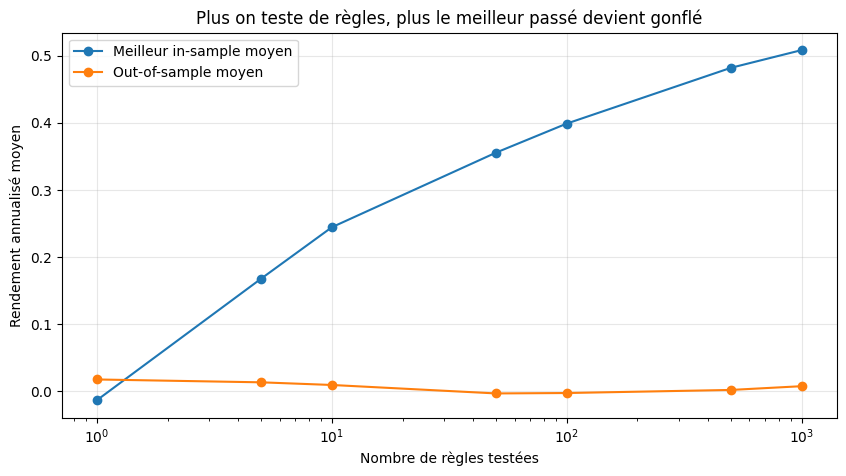

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(bias_summary["n_rules"], bias_summary["moyenne_in_sample"], marker="o", label="Meilleur in-sample moyen")
plt.plot(bias_summary["n_rules"], bias_summary["moyenne_out_of_sample"], marker="o", label="Out-of-sample moyen")
plt.xscale("log")
plt.title("Plus on teste de règles, plus le meilleur passé devient gonflé")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Rendement annualisé moyen")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

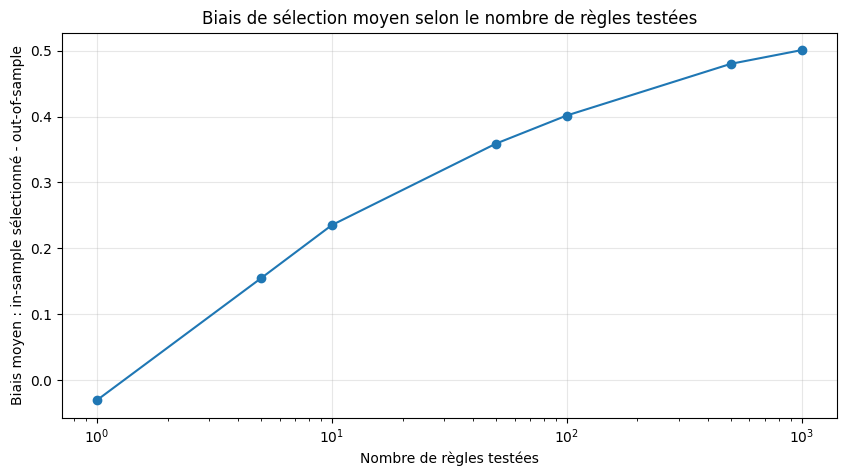

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(bias_summary["n_rules"], bias_summary["biais_moyen"], marker="o")
plt.xscale("log")
plt.title("Biais de sélection moyen selon le nombre de règles testées")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Biais moyen : in-sample sélectionné - out-of-sample")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Interprétation EBTA

Le graphique montre une idée essentielle :

> Le profit passé augmente avec le nombre d’essais, même quand aucune règle n’a de pouvoir prédictif.

Cela signifie qu’une stratégie trouvée après beaucoup d’itérations doit être traitée avec prudence.

Elle peut être :

- une vraie découverte ;
- une simple coïncidence ;
- un mélange des deux.

Le problème est qu’un simple back-test ne permet plus de faire la différence.

## 11. Tableau de diagnostic pratique

| Question | Si la réponse est oui | Conséquence |
|---|---|---|
| Ai-je testé plusieurs variantes ? | Oui | Il y a **minage de données** |
| Ai-je modifié la règle après avoir vu les résultats ? | Oui | La performance est probablement **biaisée** |
| Ai-je optimisé des paramètres ? | Oui | C’est une forme de **data mining** |
| Ai-je sélectionné la meilleure règle parmi plusieurs ? | Oui | Le score est un **critère de sélection** |
| Ai-je réservé un vrai out-of-sample ? | Non | Le risque de mirage est élevé |

> La question n’est pas seulement : “Est-ce que mon back-test est profitable ?”  
> La vraie question est : “Combien d’essais ont été nécessaires pour trouver ce profit ?”

## 12. Application directe à ton trading

Dans une démarche EBTA, tu peux classer ton travail en deux modes.

### Mode 1 — Test d’hypothèse unique

Tu pars d’une logique claire, par exemple :

> Après une prise de liquidité, un engulfing dans le sens du déséquilibre donne une opportunité exploitable.

Tu définis la règle avant de regarder les résultats.

Ensuite tu back-testes.

Dans ce cas, le résultat est plus propre statistiquement.

### Mode 2 — Exploration / minage

Tu testes plusieurs filtres :

- heure de session ;
- taille minimale de bougie ;
- type d’engulfing ;
- distance au VWAP ;
- stop-loss ;
- take-profit ;
- jour de la semaine ;
- contexte de liquidité.

Ici, tu explores un univers de règles.

Ce n’est pas interdit.

Mais tu dois reconnaître que le meilleur résultat obtenu est probablement gonflé.

## 13. Règle de discipline EBTA

Voici une règle simple :

> Si tu modifies une règle après avoir vu son résultat, tu n’es plus en train de tester une hypothèse pure.  
> Tu es entré dans une boucle de recherche.

Ce n’est pas une faute.

Mais cela change le niveau de preuve exigé.

Une règle issue du minage doit être validée par :

- un vrai **out-of-sample** ;
- une période **walk-forward** ;
- un test de robustesse ;
- une correction du biais de sélection ;
- une analyse du nombre total d’essais effectués.

## 14. Eurêka final

> Le back-test unique répond à la question :  
> **“Cette idée fonctionne-t-elle ?”**

> Le minage de données répond à une autre question :  
> **“Parmi toutes les idées essayées, laquelle a eu le plus de chance sur ce passé précis ?”**

La différence est énorme.

Dans le premier cas, le profit observé peut être une mesure.

Dans le second cas, le profit observé est d’abord un trophée de sélection.

Et un trophée de sélection n’est pas encore une preuve de robustesse.

## 15. Résumé opérationnel

| Concept | À retenir |
|---|---|
| **Back-test unique** | Test linéaire d’une hypothèse définie à l’avance |
| **Data mining** | Recherche cyclique parmi plusieurs règles ou variantes |
| **Estimateur sans biais** | Résultat qui n’est pas gonflé par la sélection |
| **Critère de sélection** | Résultat choisi parce qu’il est le meilleur parmi plusieurs |
| **Biais de sélection** | Écart entre la performance passée sélectionnée et la performance future probable |
| **Out-of-sample** | Test indépendant permettant de vérifier la robustesse |

Le message clé est simple :

> Plus tu cherches longtemps, moins le meilleur résultat trouvé sur le passé doit être cru naïvement.

## Annexe — Source collée par l’utilisateur

### **SINGLE-RULE BACK-TESTING VERSUS DATA MINING**

Voici l’analyse technique distinguant le back-test d'une règle unique du minage de données, une distinction cruciale pour la validité des conclusions d'un trader.

#### **Idées clés :**
*   **Absence de minage :** Le back-testing n'est pas synonyme de minage de données ; il ne le devient que lorsque plusieurs règles sont comparées.
*   **Processus linéaire vs cyclique :** Le test d'une règle unique s'arrête en cas d'échec, tandis que le minage de données boucle jusqu'à l'obtention d'un résultat satisfaisant.
*   **Nature de l'estimateur :** La performance d'une règle unique est un estimateur sans biais (unbiased), alors que celle d'une règle minée est un critère de sélection (selection criterion),.
*   **Garantie de succès passé :** Le minage de données garantit la découverte d'une règle performante sur le passé par la simple étendue illimitée de la recherche,.

#### **Référence :**
*Single-Rule Back-Testing versus Data Mining*, Chapitre 6, pages 268 à 271.

#### **Citation Directe :**
« Not all back testing is data mining. When just a single rule is proposed and back tested, there is no data mining. » (Page 268).

---

#### **Vision Macro :**
L'enjeu est de comprendre la source de la performance. David Aronson explique que la valeur prédictive attribuée à un back-test dépend entièrement du processus qui a mené à sa sélection. Si vous testez une idée isolée issue d'une théorie solide, le résultat est une mesure honnête de cette idée. Si vous testez, modifiez, et re-testez jusqu'à ce que "ça marche", vous ne validez plus une idée, vous séléctionnez une coïncidence statistique,. La confusion entre ces deux approches est la cause principale des déceptions en trading réel.

---

#### **Vision Micro :**

1.  **Le Back-test d'une règle unique (Figure 6.2) :**
    *   **Mécanisme :** Le chercheur a une idée, la programme, et la teste une seule fois. 
    *   **Issue :** Si le résultat est insatisfaisant, la recherche s'arrête (Aronson plaisante en disant qu'il faut alors "trouver un job chez McDonalds").
    *   **Propriété statistique :** Le profit observé est un **estimateur sans biais** de la performance future. Cela signifie que la règle a autant de chances de faire mieux que de faire moins bien que son back-test.

2.  **Le Minage de données (Figure 6.3) :**
    *   **Mécanisme :** Si le premier test échoue, la règle est affinée ou une nouvelle règle est définie. Le cycle continue (Data Mining Loop) jusqu'à ce qu'une règle performante apparaisse.
    *   **Issue :** On teste des dizaines, des centaines ou des milliers de variantes.
    *   **Propriété statistique :** La performance n'est plus un estimateur du futur mais un **critère de sélection**. Elle est mathématiquement **biaisée à la hausse** car elle représente le maximum de chance trouvé dans un échantillon donné,.

---

#### **Résumé Simplifié :**
Tester une seule stratégie, c'est comme passer un examen : ta note reflète ton niveau. Faire du minage de données, c'est repasser le même examen 100 fois jusqu'à avoir 20/20 par chance. Ta note de 20/20 ne reflète pas ton intelligence, mais seulement le fait que tu as fini par tomber sur les questions que tu connaissais,.

---

#### **Actions Concrètes :**
*   **Définissez votre mode de recherche :** Avant de commencer, décidez si vous testez une hypothèse unique ou si vous explorez un univers.
*   **Tracez vos itérations :** Si vous changez ne serait-ce qu'un paramètre après avoir vu le résultat, vous êtes entré dans la boucle du minage de données.
*   **Ajustez vos attentes :** Si votre stratégie est le résultat d'une optimisation (minage), vous ne pouvez pas utiliser son profit passé comme prévision pour le futur sans correction statistique,.

---

#### **À retenir absolument :**
*   Le back-test simple est **linéaire** ; le minage est **cyclique**.
*   Une règle unique offre une estimation **honnête** (sans biais).
*   Optimiser les paramètres **est** une forme de minage de données.
*   Le profit d'une règle minée est un **mirage** s'il n'est pas corrigé.
*   Plus vous cherchez, plus la performance passée devient un **mauvais prédicteur** du futur.

J'ai terminé l'analyse de la section comparant le back-test d'une règle unique au minage de données selon le protocole EBTA.